# Compute Z-scores and nRMSE for areas <200m
# SPEAR-LO

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file

## SPEAR-LO (1981-2010)

### 200m bathymetry mask

In [2]:
deptho = xr.open_dataset('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-HI/ocean.static.nc', chunks={})
carib = deptho.deptho.sel(yh=slice(10, 31), xh=slice(-98,-16))

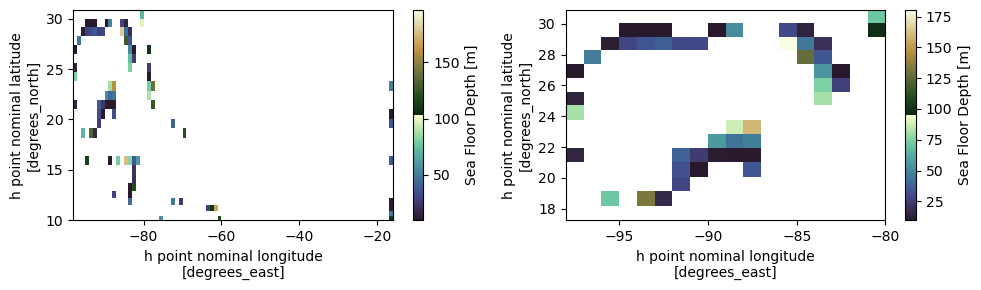

In [3]:
fig, (ax0,ax1) = plt.subplots(1,2,figsize=(10,3))
carib.where(carib<=200).plot(cmap=cmocean.cm.topo, ax=ax0)
carib.where(carib<=200).sel(yh=slice(17.5, None), xh=slice(None, -80)).plot(cmap=cmocean.cm.topo, ax=ax1)
plt.tight_layout();

In [4]:
mask_h = ~carib.where(carib<=200).isnull()
mask = mask_h.rename({'xh':'xT', 'yh':'yT'})

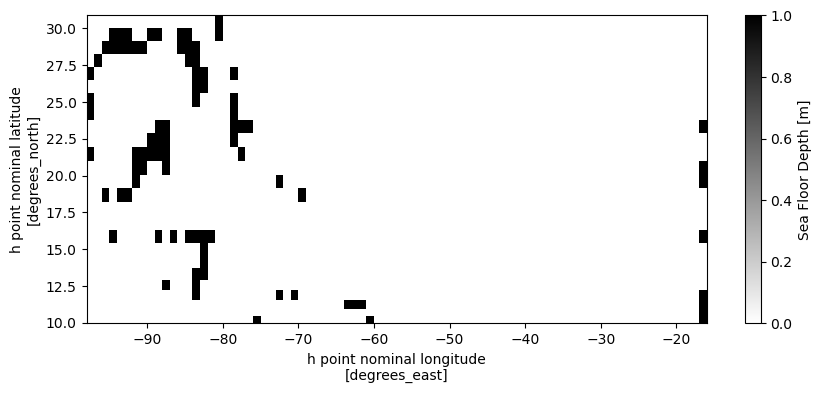

In [5]:
mask.plot(figsize=(10,4), cmap='binary');

### Compute

In [6]:
#ERA
ev_ct_ng_era = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/ev_ct_ng_era.nc',
                                 chunks={})#-
freq_ng_era = ev_ct_ng_era.mean('time')
freq_ng_std_era = ev_ct_ng_era.std('time')
int_ng_era = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/int_yrly_ng_era.nc',
                                 chunks={})
int_ng_std_era = int_ng_era.std('time')
dur_ng_era = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/med_dur_ng_era.nc',
                                 chunks={})
dur_ng_std_era = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/med_dur_std_ng_era.nc',
                                 chunks={})
#OISST
ev_ct_ng_oi = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/ev_ct_ng_oi.nc',
                                 chunks={})#-
freq_ng_oi = ev_ct_ng_oi.mean('time')
freq_ng_std_oi = ev_ct_ng_oi.std('time')
int_ng_oi = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/int_yrly_ng_oi.nc',
                                 chunks={})
int_ng_std_oi = int_ng_oi.std('time')
dur_ng_oi = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/med_dur_ng_oi.nc',
                                 chunks={})
dur_ng_std_oi = xr.open_dataarray('/work/Shanice.Bailey/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/ng_vars/med_dur_std_ng_oi.nc',
                                 chunks={})

In [7]:
%%time
#open SPEAR-LO vars
#Compute ensemble mean
files = sorted(glob.glob('/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/event_freq_splo*.nc'))
frequency_splo = []
for f in files:
    ds = xr.open_dataset(f, chunks={})
    da = next(iter(ds.data_vars.values()))
    #take the # in filename and add it to darr name
    ens = os.path.basename(f).split('_lo')[-1].split('.nc')[0] 
    da = da.rename(f'{ens}')
    frequency_splo.append(da)
stacked_freq = xr.concat(frequency_splo, dim="ensemble")
frequency_ens_mean = stacked_freq.mean('ensemble')

#mean intensity for each ensemble member
files = sorted(glob.glob('/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/mhw_intensity_splo*.nc'))
intensity_splo = []
for f in files:
    ds = xr.open_dataset(f, chunks={})
    da = next(iter(ds.data_vars.values()))
    #take the # in filename and add it to darr name
    ens = os.path.basename(f).split('_lo')[-1].split('.nc')[0] 
    da = da.rename(f'{ens}')
    intensity_splo.append(da)
stacked_mhw_int = xr.concat(intensity_splo, dim="ensemble")
intensity_ens_mean = stacked_mhw_int.mean('ensemble')

median_duration_splo = xr.open_dataarray('/work5/stb/MHW-gfdl/SPEAR/vars/SPEAR-LO/map_vars/median_duration.nc',
                                        chunks={})
median_duration_ens_mean = median_duration_splo.mean('ensemble')

CPU times: user 402 ms, sys: 51 ms, total: 453 ms
Wall time: 2.97 s


In [8]:
frequency_ens_mean

<xarray.DataArray 'event_freq_splo01' (yT: 26, xT: 83)> Size: 17kB
dask.array<mean_agg-aggregate, shape=(26, 83), dtype=float64, chunksize=(26, 83), chunktype=numpy.ndarray>
Coordinates:
  * yT         (yT) float64 208B 10.2 10.67 11.22 11.85 ... 29.59 30.46 31.31
  * xT         (xT) float64 664B -98.5 -97.5 -96.5 -95.5 ... -18.5 -17.5 -16.5
    time       object 8B 1981-09-01 12:00:00
    month      int64 8B 9
    quantile   float64 8B 0.9
    dayofyear  int64 8B 244

In [9]:
intensity_ens_mean

<xarray.DataArray 'mhw_intensity_splo01' (yT: 26, xT: 83)> Size: 17kB
dask.array<mean_agg-aggregate, shape=(26, 83), dtype=float64, chunksize=(26, 83), chunktype=numpy.ndarray>
Coordinates:
  * yT        (yT) float64 208B 10.2 10.67 11.22 11.85 ... 29.59 30.46 31.31
  * xT        (xT) float64 664B -98.5 -97.5 -96.5 -95.5 ... -18.5 -17.5 -16.5
    quantile  float64 8B 0.9

In [10]:
median_duration_ens_mean

<xarray.DataArray (yT: 26, xT: 83)> Size: 17kB
dask.array<mean_agg-aggregate, shape=(26, 83), dtype=float64, chunksize=(26, 83), chunktype=numpy.ndarray>
Coordinates:
  * yT       (yT) float64 208B 10.2 10.67 11.22 11.85 ... 29.59 30.46 31.31
  * xT       (xT) float64 664B -98.5 -97.5 -96.5 -95.5 ... -18.5 -17.5 -16.5

In [11]:
#Z-score
rn = {'lat':'yT', 'lon':'xT'}
rn_tude = {'latitude':'yT', 'longitude':'xT'}

freqo = freq_ng_oi.rename(**rn)
freqo_std = freq_ng_std_oi.rename(**rn)
freqe = freq_ng_era.rename(**rn)
freqe_std = freq_ng_std_era.rename(**rn)

duro = dur_ng_oi.rename(**rn)
duro_std = dur_ng_std_oi.rename(**rn)
dure = dur_ng_era.rename(**rn_tude)
dure_std = dur_ng_std_era.rename(**rn_tude)

into = int_ng_oi.drop_vars(('quantile','dayofyear','month')).rename(**rn)
into_std = int_ng_std_oi.drop_vars('quantile').rename(**rn)
inte = int_ng_era.rename(**rn_tude)
inte_std = int_ng_std_era.rename(**rn_tude)

#----------------------------------------------------------------------------------

zscore_freq_oi = (frequency_ens_mean.drop_vars(('quantile','dayofyear','month', 'time')) - freqo) / freqo_std.where(freqo_std>0)
zscore_freq_era = (frequency_ens_mean.drop_vars(('quantile','dayofyear','month', 'time')) - freqe) / freqe_std.where(freqe_std>0)

zscore_int_oi = (intensity_ens_mean.drop_vars('quantile') - into.mean('time')) / into_std
zscore_int_era = (intensity_ens_mean.drop_vars('quantile') - inte.mean('time')) / inte_std

zscore_dur_oi = (median_duration_ens_mean - duro) / duro_std
zscore_dur_era = (median_duration_ens_mean - dure) / dure_std

In [12]:
zscore_freq_oi200 = zscore_freq_oi.where(mask)
zscore_freq_era200 = zscore_freq_era.where(mask)

zscore_int_oi200 = zscore_int_oi.where(mask)
zscore_int_era200 = zscore_int_era.where(mask)

zscore_dur_oi200 = zscore_dur_oi.where(mask)
zscore_dur_era200 = zscore_dur_era.where(mask)

In [13]:
abs(zscore_freq_oi200).mean().values

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


array(0.92375293)

In [14]:
abs(zscore_dur_oi200).mean().values

array(0.39651806)

In [15]:
abs(zscore_int_oi200).mean().values

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


array(0.22490511)

<p style="text-align: center;">Z-scores at 200m bathymetry</p>

| Z-score $\overline{S} - O$ | Freq | Duration | Intensity |
| --------- | -------| -------|  -------|
| OISST | 0.924 | 0.40 | 0.22 |
| ERA5 | 0.79 | 0.18 | 0.18 |
| ERA5/OISST | ? | ? | ? |

| $\vert$ Z-score $\vert$|    Meaning                                                         |
| --------- | --------------------------------------------------------------- |
| **< 0.5** | Small difference |
| **~ 1.0** | Model differs by 1 std              |
| **> 2**   | Large discrepancy                          |


### Z-score Maps

In [16]:
def cartopy_plot_single(da, cmap_choice, cbar_label, var_title, vmin=None, vmax=None, norm=None, quiver=True):
    proj = ccrs.Mercator() #with Mercator you can put lat lon values.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=proj))
    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face',
                                            facecolor='0.5'))
    # ---- infer coord names if not provided ----
    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']

    lat_name = next((c for c in lat_candidates if c in da.coords), None)
    lon_name = next((c for c in lon_candidates if c in da.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not infer lat/lon coordinates. "
            f"Found coords: {list(da.coords)}"
        )

    lats = da[lat_name]
    lons = da[lon_name]

    # ---- normalization logic ----
    if norm is None:
        # simple linear scaling
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        # override norm limits if vmin/vmax are supplied
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax
    # -------------------------------------------------------------------------------
    im = ax.pcolormesh(lons, lats, da, transform=ccrs.PlateCarree(), 
                       norm=norm, cmap=cmap_choice)
    cb = fig.colorbar(im, ax=ax, shrink=0.25, pad=0.1)
    cb.set_label(fr"{cbar_label}", labelpad=8, fontsize=12)
    g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    g1.xlabels_top = False
    g1.ylabels_right = False
    plt.title(f'{var_title}', fontsize=14, y=1.09)

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


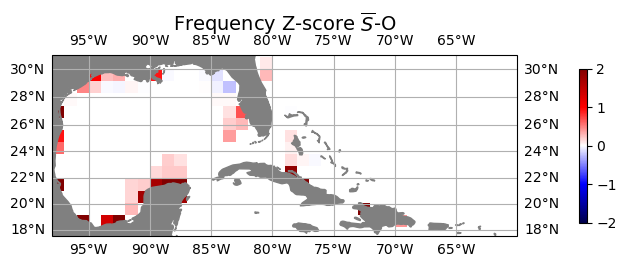

In [17]:
cartopy_plot_single(zscore_freq_oi200, 'seismic', '', r'Frequency Z-score $\overline{S}$-O', vmin=-2, vmax=2);

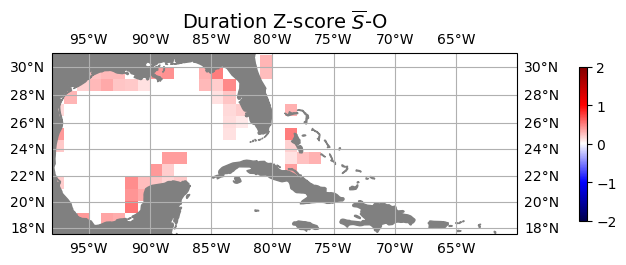

In [18]:
cartopy_plot_single(zscore_dur_oi200, 'seismic', '', r'Duration Z-score $\overline{S}$-O', vmin=-2, vmax=2);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


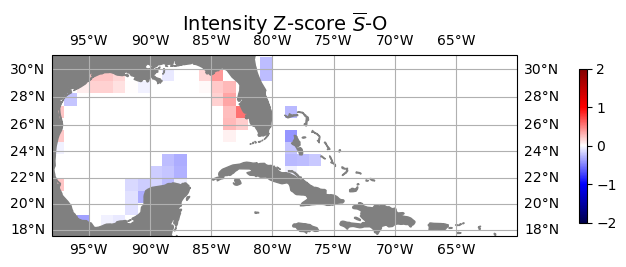

In [19]:
cartopy_plot_single(zscore_int_oi200, 'seismic', '', r'Intensity Z-score $\overline{S}$-O', vmin=-2, vmax=2);

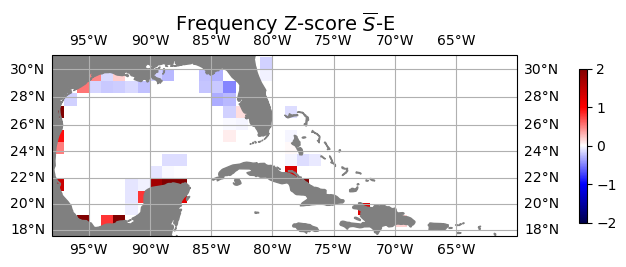

In [20]:
cartopy_plot_single(zscore_freq_era200, 'seismic', '', r'Frequency Z-score $\overline{S}$-E', vmin=-2, vmax=2);

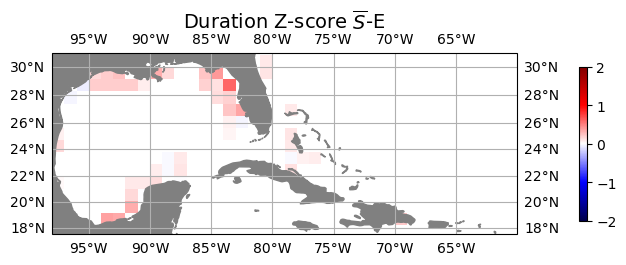

In [21]:
cartopy_plot_single(zscore_dur_era200, 'seismic', '', r'Duration Z-score $\overline{S}$-E', vmin=-2, vmax=2);

/home/Shanice.Bailey/.local/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


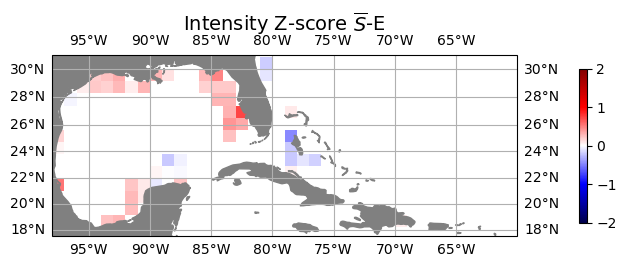

In [22]:
cartopy_plot_single(zscore_int_era200, 'seismic', '', r'Intensity Z-score $\overline{S}$-E', vmin=-2, vmax=2);

### nRMSEs

In [31]:
def nrmse_std_norm(model, obs):
    """
    nRMSE normalized by spatial standard deviation of observations
    """
    rmse = np.sqrt(((model - obs) ** 2).mean())
    norm = obs.std()
    return rmse / norm

In [29]:
med_dur_200m = median_duration_ens_mean.where(mask)
freq_200m = frequency_ens_mean.drop_vars(('quantile','dayofyear','month', 'time')).where(mask)
int_200m = intensity_ens_mean.drop_vars('quantile').where(mask)

In [34]:
nrmse_freq_oi = nrmse_std_norm(freq_200m, freqo.where(mask)).values
nrmse_duration_oi = nrmse_std_norm(med_dur_200m, duro.where(mask)).values
nrmse_intensity_oi = nrmse_std_norm(int_200m, into.where(mask)).values

nrmse_freq_era = nrmse_std_norm(freq_200m, freqe.where(mask)).values
nrmse_duration_era = nrmse_std_norm(med_dur_200m, dure.where(mask)).values
nrmse_intensity_era = nrmse_std_norm(int_200m, inte.where(mask)).values

#nrmse_freq_oe = nrmse_std_norm(event_count_yearly_era.mean('time'), freq_ng_oe).values
#nrmse_duration_oe = nrmse_std_norm(median_duration_per_cell_era, med_dur_ng_oe).values
#nrmse_intensity_oe = nrmse_std_norm(mhw_intensity_yearly_era.mean('time'), int_ng_oe).values

In [38]:
nrmse_freq_oi

array(1.37157446)

In [39]:
nrmse_duration_oi

array(4.47572848)

In [40]:
nrmse_intensity_oi

array(1.00564824)

<p style="text-align: center;">nRMSE at 200m bathymetry</p>

| $\overline{S} - O$ | Freq | Duration | Intensity |
| --------- | -------| -------|  -------|
| OISST | 1.37 | 4.48 | 1.01 |
| ERA5 | 1.08 | 2.74 | 0.99 |
| ERA5/OISST | ? | ? | ? |

| nRMSE     | Meaning                                                         |
| --------- | --------------------------------------------------------------- |
| **< 0.5** | Model errors are small relative to observed spatial variability |
| **~ 1.0** | Model error equals typical observed spatial spread              |
| **1–2**   | Model errors large relative to real-world variability           |
| **> 2**   | Model performs poorly for this metric                           |
